Best Parameters from Grid Search:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

=== Random Forest — Test Metrics ===
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000
ROC-AUC  : 1.0000

Confusion Matrix:
[[12  0]
 [ 0 24]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        24

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



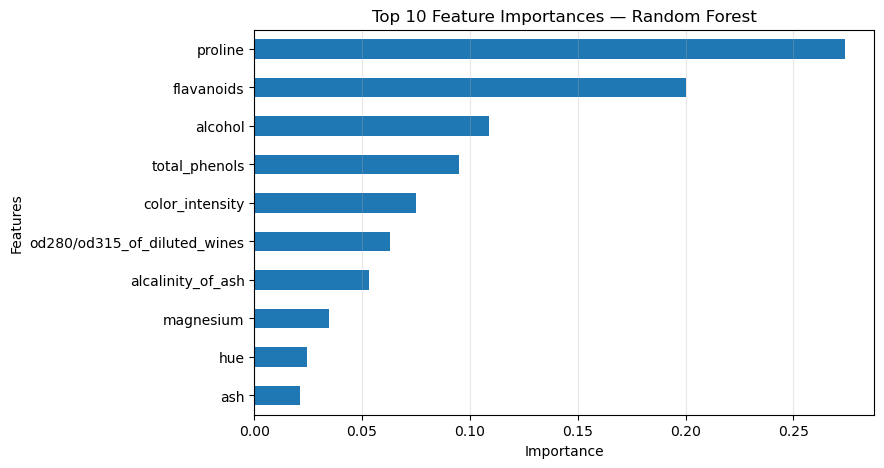

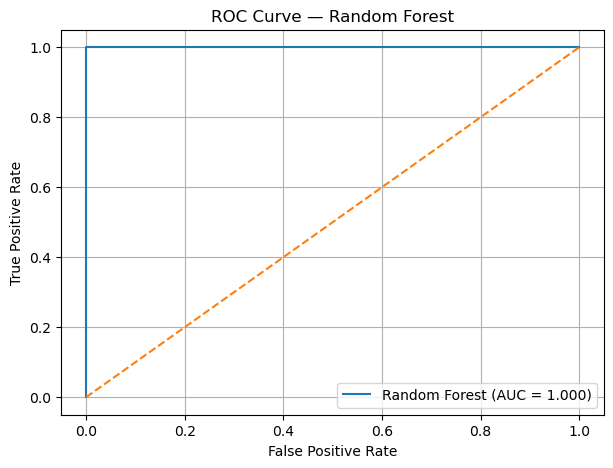

In [1]:
# ===========================================
# EXPERIMENT 4B — Random Forest Classifier
# ===========================================

# 1) Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)


# 2) Load Dataset

wine = load_wine()

X = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

y = pd.Series(
    wine.target,
    name="target"
)


# 3) Convert into Binary Classification

# Class 0 = 0
# Classes 1 and 2 = 1

y = (y != 0).astype(int)


# 4) Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# 5) Define Random Forest Model

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)


# 6) Hyperparameter Grid and Tuning

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}


grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=0
)


grid.fit(X_train, y_train)


print("Best Parameters from Grid Search:")
print(grid.best_params_)

best_rf = grid.best_estimator_


# 7) Train Final Model and Predict

best_rf.fit(X_train, y_train)

y_pred = best_rf.predict(X_test)

y_prob = best_rf.predict_proba(X_test)[:, 1]


# 8) Evaluate the Model

acc = accuracy_score(y_test, y_pred)

prec = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

rec = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

auc = roc_auc_score(y_test, y_prob)

cm = confusion_matrix(y_test, y_pred)


print("\n=== Random Forest — Test Metrics ===")

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")


print("\nConfusion Matrix:")
print(cm)


print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)


# 9) Feature Importance — Top 10

importances = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
)

top10 = importances.sort_values(
    ascending=False
).head(10)


plt.figure(figsize=(8, 5))

top10[::-1].plot(
    kind="barh"
)

plt.xlabel("Importance")
plt.ylabel("Features")

plt.title(
    "Top 10 Feature Importances — Random Forest"
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.show()


# 10) ROC Curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)


plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve — Random Forest")

plt.legend()
plt.grid(True)

plt.show()